# Iteration v3 — Adding User Activity Features

Previous best: **Random Forest, ROC AUC 0.6727** (iteration v2, transaction + member features only).

This iteration adds listening behavior from `user_logs_v2.csv` (March 2017 activity window).
The hypothesis: knowing whether a user actually used the product is more predictive than knowing how they paid for it.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report
)

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("LightGBM not installed. Run: pip install lightgbm")

RANDOM_STATE = 42
print(f"LightGBM available: {LGBM_AVAILABLE}")

LightGBM available: True


## 1. Load & Merge

In [11]:
baseline = pd.read_csv('../data/processed/df_model_baseline_v1.csv')
log_feats = pd.read_csv('../data/processed/log_features_march2017.csv')

# Parse dates needed for recency features
baseline['txn_last_date']  = pd.to_datetime(baseline['txn_last_date'])
baseline['txn_first_date'] = pd.to_datetime(baseline['txn_first_date'])

print(f"Baseline shape : {baseline.shape}")
print(f"Log feats shape: {log_feats.shape}")
print(f"Churn rate     : {baseline['is_churn'].mean():.2%}")

Baseline shape : (970960, 21)
Log feats shape: (970960, 12)
Churn rate     : 8.99%


In [12]:
df = baseline.merge(log_feats, on='msno', how='left')

has_logs = df['total_secs_sum'].notna()
print(f"Users with log activity : {has_logs.sum():>10,}  ({has_logs.mean():.1%})")
print(f"Users with no activity  : {(~has_logs).sum():>10,}  ({(~has_logs).mean():.1%})")
print()
print(f"Churn rate — active users  : {df[has_logs]['is_churn'].mean():.2%}")
print(f"Churn rate — inactive users: {df[~has_logs]['is_churn'].mean():.2%}")

Users with log activity :    970,960  (100.0%)
Users with no activity  :          0  (0.0%)

Churn rate — active users  : 8.99%
Churn rate — inactive users: nan%


## 2. Feature Engineering

Rebuilding v2 derived features, then adding log features on top.

In [13]:
CUTOFF = pd.Timestamp('2017-02-28')

df['days_since_last_txn'] = (CUTOFF - df['txn_last_date']).dt.days
df['days_since_last_txn'] = df['days_since_last_txn'].fillna(df['days_since_last_txn'].max() + 1)
df['has_recent_txn']  = (df['days_since_last_txn'] < 30).astype(int)
df['txn_per_day']     = df['txn_count'] / (df['days_between_first_last_txn'].fillna(0) + 1)
df['avg_payment']     = df['actual_amount_paid_median'].fillna(0)
df['price_discount']  = (df['plan_list_price_last'].fillna(0) - df['actual_amount_paid_last'].fillna(0)).clip(lower=0)
df['plan_consistency'] = (
    df['payment_plan_days_last'].fillna(-1) == df['payment_plan_days_median'].fillna(-2)
).astype(int)

In [14]:
# Features from v1 baseline
FEATURES_V1 = [
    'txn_count', 'has_txn_history', 'auto_renew_last',
    'payment_plan_days_last', 'plan_list_price_last', 'actual_amount_paid_last',
    'cancel_count', 'has_cancelled', 'days_since_registration',
]

# New transaction features added in v2
FEATURES_TXN_NEW = [
    'days_since_last_txn', 'has_recent_txn', 'txn_per_day',
    'avg_payment', 'price_discount', 'plan_consistency',
]

# New user log features
FEATURES_LOGS = [
    'total_secs_sum', 'total_secs_mean', 'active_days',
    'num_100_sum', 'num_unq_sum', 'num_unq_mean',
    'completion_rate', 'days_since_last_log',
    'has_recent_activity', 'peak_day_secs', 'activity_cv',
]

FEATURES_V3 = FEATURES_V1 + FEATURES_TXN_NEW + FEATURES_LOGS

print(f"Total features: {len(FEATURES_V3)}")
print(f"  v1 baseline  : {len(FEATURES_V1)}")
print(f"  txn new (v2) : {len(FEATURES_TXN_NEW)}")
print(f"  log features : {len(FEATURES_LOGS)}")

Total features: 26
  v1 baseline  : 9
  txn new (v2) : 6
  log features : 11


## 3. Train / Validation Split

In [15]:
X = df[FEATURES_V3].fillna(0)
y = df['is_churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")
print(f"Churn rate in val: {y_val.mean():.2%}")

Train: (776768, 26)  |  Val: (194192, 26)
Churn rate in val: 8.99%


## 4. Evaluation Helper

In [16]:
def evaluate(name, model, X_val, y_val, threshold=0.5):
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    metrics = dict(
        model     = name,
        roc_auc   = roc_auc_score(y_val, y_proba),
        accuracy  = accuracy_score(y_val, y_pred),
        precision = precision_score(y_val, y_pred, zero_division=0),
        recall    = recall_score(y_val, y_pred, zero_division=0),
        f1        = f1_score(y_val, y_pred, zero_division=0),
    )

    print(f"\n{'─'*52}")
    print(f"  {name}")
    print(f"{'─'*52}")
    print(f"  ROC AUC   {metrics['roc_auc']:.4f}")
    print(f"  Accuracy  {metrics['accuracy']:.4f}")
    print(f"  Precision {metrics['precision']:.4f}")
    print(f"  Recall    {metrics['recall']:.4f}")
    print(f"  F1        {metrics['f1']:.4f}")
    print()
    print(classification_report(y_val, y_pred, target_names=['no churn', 'churn']))

    return metrics

## 5. Models

### 5.1 Random Forest — same config as v2 (fair comparison)

In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
res_rf = evaluate('Random Forest — v3 features (depth=10, balanced)', rf, X_val, y_val)


────────────────────────────────────────────────────
  Random Forest — v3 features (depth=10, balanced)
────────────────────────────────────────────────────
  ROC AUC   0.7651
  Accuracy  0.8329
  Precision 0.2824
  Recall    0.5565
  F1        0.3747

              precision    recall  f1-score   support

    no churn       0.95      0.86      0.90    176726
       churn       0.28      0.56      0.37     17466

    accuracy                           0.83    194192
   macro avg       0.62      0.71      0.64    194192
weighted avg       0.89      0.83      0.86    194192



### 5.2 Random Forest — deeper

With more features, a deeper tree can capture richer interactions without overfitting as aggressively.

In [18]:
rf_deep = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_deep.fit(X_train, y_train)
res_rf_deep = evaluate('Random Forest — deeper (depth=15, n=200)', rf_deep, X_val, y_val)


────────────────────────────────────────────────────
  Random Forest — deeper (depth=15, n=200)
────────────────────────────────────────────────────
  ROC AUC   0.7675
  Accuracy  0.8448
  Precision 0.3005
  Recall    0.5467
  F1        0.3878

              precision    recall  f1-score   support

    no churn       0.95      0.87      0.91    176726
       churn       0.30      0.55      0.39     17466

    accuracy                           0.84    194192
   macro avg       0.63      0.71      0.65    194192
weighted avg       0.89      0.84      0.86    194192



### 5.3 LightGBM

Gradient boosting on decision trees. Typically outperforms Random Forest on tabular data with moderate feature counts.

In [19]:
if LGBM_AVAILABLE:
    lgbm = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    lgbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
    )
    res_lgbm = evaluate('LightGBM (n=500, lr=0.05, depth=6)', lgbm, X_val, y_val)
else:
    print("Skipping LightGBM — not installed.")
    res_lgbm = None

[100]	valid_0's binary_logloss: 0.524159
[200]	valid_0's binary_logloss: 0.517066
[300]	valid_0's binary_logloss: 0.514567
[400]	valid_0's binary_logloss: 0.51269
[500]	valid_0's binary_logloss: 0.511132

────────────────────────────────────────────────────
  LightGBM (n=500, lr=0.05, depth=6)
────────────────────────────────────────────────────
  ROC AUC   0.7761
  Accuracy  0.8323
  Precision 0.2842
  Recall    0.5696
  F1        0.3792

              precision    recall  f1-score   support

    no churn       0.95      0.86      0.90    176726
       churn       0.28      0.57      0.38     17466

    accuracy                           0.83    194192
   macro avg       0.62      0.71      0.64    194192
weighted avg       0.89      0.83      0.86    194192



## 6. Results Comparison

In [20]:

history = [
    {'model': 'Logistic Regression — v1 (baseline)',       'roc_auc': 0.5673, 'accuracy': 0.9143, 'precision': 0.7808, 'recall': 0.0649, 'f1': 0.1198},
    {'model': 'Decision Tree      — v2 features',          'roc_auc': 0.6038, 'accuracy': 0.9200, 'precision': 0.7674, 'recall': 0.1588, 'f1': 0.2632},
    {'model': 'Random Forest      — v2 features (depth=10)','roc_auc': 0.6727, 'accuracy': 0.7256, 'precision': 0.1611, 'recall': 0.4875, 'f1': 0.2421},
]

current = [res_rf, res_rf_deep]
if res_lgbm:
    current.append(res_lgbm)

results = pd.DataFrame(history + current).set_index('model')
results = results.sort_values('roc_auc', ascending=False)

print(results.round(4).to_string())

                                                  roc_auc  accuracy  precision  recall      f1
model                                                                                         
LightGBM (n=500, lr=0.05, depth=6)                 0.7761    0.8323     0.2842  0.5696  0.3792
Random Forest — deeper (depth=15, n=200)           0.7675    0.8448     0.3005  0.5467  0.3878
Random Forest — v3 features (depth=10, balanced)   0.7651    0.8329     0.2824  0.5565  0.3747
Random Forest      — v2 features (depth=10)        0.6727    0.7256     0.1611  0.4875  0.2421
Decision Tree      — v2 features                   0.6038    0.9200     0.7674  0.1588  0.2632
Logistic Regression — v1 (baseline)                0.5673    0.9143     0.7808  0.0649  0.1198


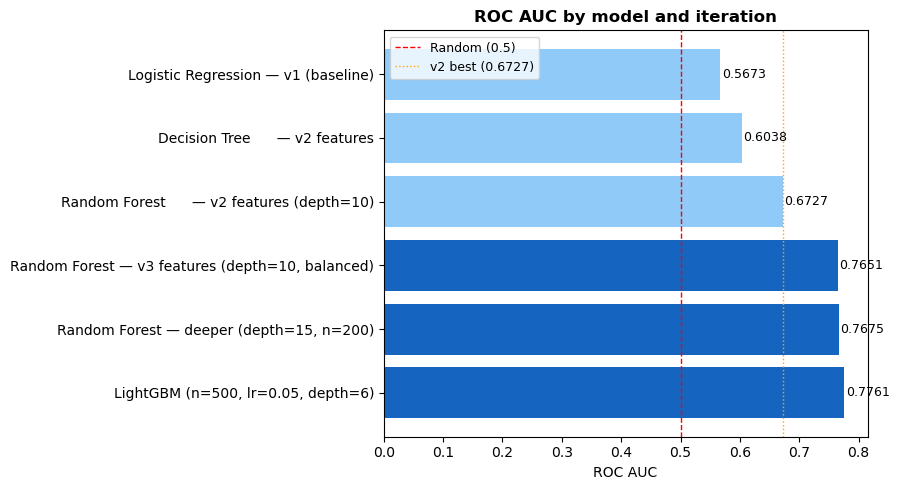

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#90CAF9' if 'v1' in m or 'v2' in m else '#1565C0' for m in results.index]
bars = ax.barh(results.index, results['roc_auc'], color=colors)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='Random (0.5)')
ax.axvline(0.6727, color='orange', linestyle=':', linewidth=1, label='v2 best (0.6727)')
ax.set_xlabel('ROC AUC')
ax.set_title('ROC AUC by model and iteration', fontweight='bold')
ax.legend(fontsize=9)
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Feature Importance

Using the best Random Forest model.

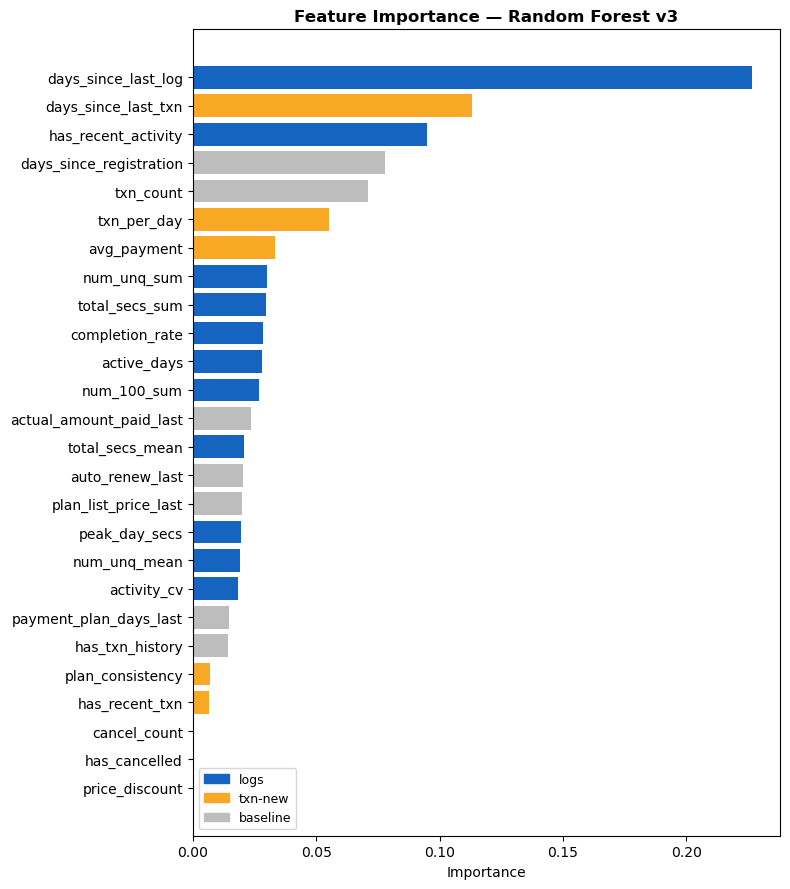

                feature   source  importance
    days_since_last_log     logs    0.226579
    days_since_last_txn  txn-new    0.113128
    has_recent_activity     logs    0.094935
days_since_registration baseline    0.078078
              txn_count baseline    0.070860
            txn_per_day  txn-new    0.055259
            avg_payment  txn-new    0.033170
            num_unq_sum     logs    0.030185
         total_secs_sum     logs    0.029830
        completion_rate     logs    0.028311
            active_days     logs    0.027953
            num_100_sum     logs    0.026984
actual_amount_paid_last baseline    0.023521
        total_secs_mean     logs    0.020750
        auto_renew_last baseline    0.020169
   plan_list_price_last baseline    0.020100
          peak_day_secs     logs    0.019539
           num_unq_mean     logs    0.019103
            activity_cv     logs    0.018274
 payment_plan_days_last baseline    0.014791
        has_txn_history baseline    0.014147
       pla

In [22]:
best_rf = rf_deep

importance = (
    pd.DataFrame({'feature': FEATURES_V3, 'importance': best_rf.feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

# Tag each feature by source
def tag(f):
    if f in FEATURES_LOGS:    return 'logs'
    if f in FEATURES_TXN_NEW: return 'txn-new'
    return 'baseline'

importance['source'] = importance['feature'].map(tag)

palette = {'logs': '#1565C0', 'txn-new': '#F9A825', 'baseline': '#BDBDBD'}

fig, ax = plt.subplots(figsize=(8, 9))
for _, row in importance.iterrows():
    ax.barh(row['feature'], row['importance'], color=palette[row['source']])
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Feature Importance — Random Forest v3', fontweight='bold')

from matplotlib.patches import Patch
legend = [Patch(color=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.show()

print(importance[['feature', 'source', 'importance']].to_string(index=False))

### Feature group contribution

In [23]:
group_importance = importance.groupby('source')['importance'].sum().sort_values(ascending=False)
print("Importance share by feature group:")
for source, val in group_importance.items():
    print(f"  {source:<12} {val:.3f}  ({val:.1%})")

Importance share by feature group:
  logs         0.542  (54.2%)
  baseline     0.242  (24.2%)
  txn-new      0.215  (21.5%)


## 8. Threshold Analysis — Best Model

In [24]:
# Use LightGBM if available, otherwise best RF
best_model = lgbm if LGBM_AVAILABLE else rf_deep
best_name  = 'LightGBM' if LGBM_AVAILABLE else 'Random Forest (deep)'

y_proba = best_model.predict_proba(X_val)[:, 1]

rows = []
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        'threshold' : t,
        'precision' : precision_score(y_val, y_pred_t, zero_division=0),
        'recall'    : recall_score(y_val, y_pred_t, zero_division=0),
        'f1'        : f1_score(y_val, y_pred_t, zero_division=0),
        'flagged'   : y_pred_t.sum(),
    })

thr_df = pd.DataFrame(rows)
print(f"Threshold analysis — {best_name}")
print(thr_df.round(4).to_string(index=False))

Threshold analysis — LightGBM
 threshold  precision  recall     f1  flagged
       0.5     0.2842  0.5696 0.3792    35001
       0.4     0.1941  0.6820 0.3022    61379
       0.3     0.1128  0.9124 0.2007   141311
       0.2     0.0963  0.9829 0.1754   178253
       0.1     0.0905  0.9991 0.1660   192777


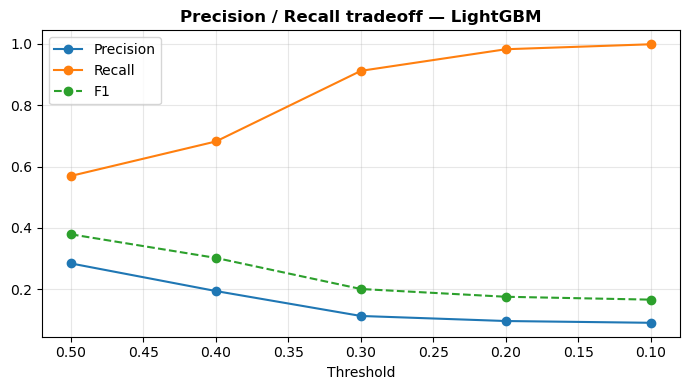

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thr_df['threshold'], thr_df['precision'], marker='o', label='Precision')
ax.plot(thr_df['threshold'], thr_df['recall'],    marker='o', label='Recall')
ax.plot(thr_df['threshold'], thr_df['f1'],        marker='o', label='F1', linestyle='--')
ax.invert_xaxis()
ax.set_xlabel('Threshold')
ax.set_title(f'Precision / Recall tradeoff — {best_name}', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Summary

Fill in after running.

**Key questions:**
- How much did log features improve ROC AUC over v2 (0.6727)?
- Which feature group (logs vs txn-new vs baseline) contributed most?
- Did `active_days` or `total_secs_sum` rank high in the RF?
- How does LightGBM compare to the best RF?

**Next steps:**
- If ROC AUC is still below 0.80, investigate the `user_logs.csv` file (pre-cutoff data) for additional signal
- Try LightGBM with hyperparameter search (Optuna or RandomizedSearchCV)
- Explore interaction features between log activity and transaction recency